# Demo 10 - Heston Monte Carlo pricing and convergence

This notebook demonstrates a compact Heston Monte Carlo workflow for a European vanilla option.

It uses the public option-pricing library objects for the contract and market inputs, then keeps the Heston simulation logic in the notebook so the modelling assumptions are reviewable:

- full-truncation Euler variance stepping,
- correlated stock/variance Brownian shocks,
- reproducible random numbers,
- confidence intervals for the discounted payoff estimate,
- convergence plots as the path count increases.

`PROFILE = "quick"` keeps execution suitable for CI and review; switch to `"full"` for a broader convergence sweep.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "option_pricing").exists():
            return candidate
    return start


ROOT = _find_repo_root(Path.cwd())
SRC = ROOT / "src"
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

PROFILE = "full"
SEED = 42


## 1) Define the contract, market, and Heston parameters

The option and market are standard library objects. The Heston parameter container is local to the notebook because this demo is focused on Monte Carlo mechanics rather than adding a new public engine.


In [2]:
from dataclasses import dataclass
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from option_pricing import (
    ExerciseStyle,
    MarketData,
    OptionType,
    VanillaOption,
    bs_price_instrument,
)


@dataclass(frozen=True, slots=True)
class HestonParams:
    v0: float
    kappa: float
    theta: float
    xi: float
    rho: float


class MCStats(NamedTuple):
    price: float
    standard_error: float
    ci_low: float
    ci_high: float


option = VanillaOption(
    expiry=1.0,
    strike=100.0,
    kind=OptionType.CALL,
    exercise=ExerciseStyle.EUROPEAN,
)
market = MarketData(spot=100.0, rate=0.03, dividend_yield=0.01)
heston = HestonParams(v0=0.04, kappa=2.0, theta=0.04, xi=0.35, rho=-0.70)

if not -1.0 <= heston.rho <= 1.0:
    raise ValueError("Heston correlation rho must be in [-1, 1].")
if min(heston.v0, heston.kappa, heston.theta, heston.xi) < 0.0:
    raise ValueError("Heston variance, mean-reversion, and vol-of-vol inputs must be non-negative.")

summary = pd.DataFrame(
    [
        {
            "spot": market.spot,
            "strike": option.strike,
            "expiry": option.expiry,
            "rate": market.rate,
            "dividend_yield": market.dividend_yield,
            "v0": heston.v0,
            "kappa": heston.kappa,
            "theta": heston.theta,
            "xi": heston.xi,
            "rho": heston.rho,
            "feller_2kappa_theta_minus_xi2": 2 * heston.kappa * heston.theta - heston.xi**2,
        }
    ]
)
display(summary)


,spot,strike,expiry,rate,dividend_yield,v0,kappa,theta,xi,rho,feller_2kappa_theta_minus_xi2
0,100.0,100.0,1.0,0.03,0.01,0.04,2.0,0.04,0.35,-0.7,0.0375


## 2) Heston path simulation

The simulator returns terminal prices only, which is enough for European vanilla options and keeps memory use low.

The variance update uses the full-truncation Euler convention: the non-negative part of variance is used in the drift and diffusion terms, and the next step is floored at zero before it is reused.


In [3]:
def simulate_heston_terminal(
    *,
    market: MarketData,
    params: HestonParams,
    expiry: float,
    n_paths: int,
    n_steps: int,
    seed: int,
) -> np.ndarray:
    """Simulate terminal stock prices under Heston using full-truncation Euler."""
    if n_paths <= 1:
        raise ValueError("n_paths must be greater than 1.")
    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")

    rng = np.random.default_rng(seed)
    dt = expiry / n_steps
    sqrt_dt = np.sqrt(dt)
    corr_scale = np.sqrt(max(1.0 - params.rho**2, 0.0))

    log_s = np.full(n_paths, np.log(market.spot), dtype=float)
    v = np.full(n_paths, params.v0, dtype=float)

    for _ in range(n_steps):
        z_var = rng.standard_normal(n_paths)
        z_independent = rng.standard_normal(n_paths)
        z_spot = params.rho * z_var + corr_scale * z_independent

        v_pos = np.maximum(v, 0.0)
        log_s += (
            (market.rate - market.dividend_yield - 0.5 * v_pos) * dt
            + np.sqrt(v_pos) * sqrt_dt * z_spot
        )
        v = (
            v
            + params.kappa * (params.theta - v_pos) * dt
            + params.xi * np.sqrt(v_pos) * sqrt_dt * z_var
        )
        v = np.maximum(v, 0.0)

    return np.exp(log_s)


def discounted_payoffs(option: VanillaOption, market: MarketData, terminal_spots: np.ndarray) -> np.ndarray:
    """Evaluate discounted terminal payoffs with the library's instrument payoff."""
    return market.df(option.expiry) * option.payoff(terminal_spots)


def summarize_mc(discounted_values: np.ndarray) -> MCStats:
    """Return price, standard error, and a normal 95% confidence interval."""
    n = discounted_values.size
    price = float(np.mean(discounted_values))
    standard_error = float(np.std(discounted_values, ddof=1) / np.sqrt(n))
    half_width = 1.96 * standard_error
    return MCStats(
        price=price,
        standard_error=standard_error,
        ci_low=price - half_width,
        ci_high=price + half_width,
    )


## 3) Price once at the largest path count

This cell simulates the largest path set once. The convergence study below reuses prefixes of these same paths, so differences across rows come from sample size rather than different random seeds.


In [4]:
if PROFILE == "quick":
    N_STEPS = 126
    PATH_COUNTS = [2_000, 5_000, 10_000, 20_000, 50_000]
elif PROFILE == "full":
    N_STEPS = 252
    PATH_COUNTS = [5_000, 10_000, 25_000, 50_000, 100_000, 200_000]
else:
    raise ValueError(f"Unsupported PROFILE: {PROFILE!r}")

MAX_PATHS = max(PATH_COUNTS)

terminal_spots = simulate_heston_terminal(
    market=market,
    params=heston,
    expiry=option.expiry,
    n_paths=MAX_PATHS,
    n_steps=N_STEPS,
    seed=SEED,
)
values = discounted_payoffs(option, market, terminal_spots)
stats = summarize_mc(values)

bs_at_sqrt_theta = bs_price_instrument(
    option,
    market=market,
    sigma=np.sqrt(heston.theta),
)

headline = pd.DataFrame(
    [
        {
            "profile": PROFILE,
            "n_steps": N_STEPS,
            "n_paths": MAX_PATHS,
            "heston_mc_price": stats.price,
            "standard_error": stats.standard_error,
            "ci_low_95": stats.ci_low,
            "ci_high_95": stats.ci_high,
            "bs_price_sigma_sqrt_theta": bs_at_sqrt_theta,
            "discounted_stock_mean": market.df(option.expiry) * float(np.mean(terminal_spots)),
            "prepaid_forward": market.spot * np.exp(-market.dividend_yield * option.expiry),
        }
    ]
)
display(headline)


,profile,n_steps,n_paths,heston_mc_price,standard_error,ci_low_95,ci_high_95,bs_price_sigma_sqrt_theta,discounted_stock_mean,prepaid_forward
0,full,252,200000,8.566577,0.024328,8.518893,8.61426,8.827321,99.025054,99.004983


## 4) Convergence table

The final row is the largest-sample estimate. Earlier rows show the running Monte Carlo estimate and confidence interval using the same simulated path ordering.


In [5]:
rows: list[dict[str, float]] = []
reference_price = stats.price

for n_paths in PATH_COUNTS:
    row_stats = summarize_mc(values[:n_paths])
    rows.append(
        {
            "n_paths": n_paths,
            "price": row_stats.price,
            "standard_error": row_stats.standard_error,
            "ci_low_95": row_stats.ci_low,
            "ci_high_95": row_stats.ci_high,
            "abs_error_vs_max_paths": abs(row_stats.price - reference_price),
            "ci_half_width_95": row_stats.ci_high - row_stats.price,
        }
    )

convergence = pd.DataFrame(rows)
display(convergence)


,n_paths,price,standard_error,ci_low_95,ci_high_95,abs_error_vs_max_paths,ci_half_width_95
0,5000,8.534090,0.156849,8.226665,8.841514,0.032487,0.307425
1,10000,8.581169,0.110589,8.364415,8.797922,0.014592,0.216754
2,25000,8.561784,0.069384,8.425791,8.697777,0.004793,0.135993
3,50000,8.616982,0.048985,8.520971,8.712992,0.050405,0.096011
4,100000,8.618149,0.034513,8.550504,8.685794,0.051572,0.067645
5,200000,8.566577,0.024328,8.518893,8.614260,0.000000,0.047684


## 5) Plot price convergence

The error bars are normal 95% confidence intervals around the discounted payoff mean. The dashed reference line is the largest-sample estimate from this run.


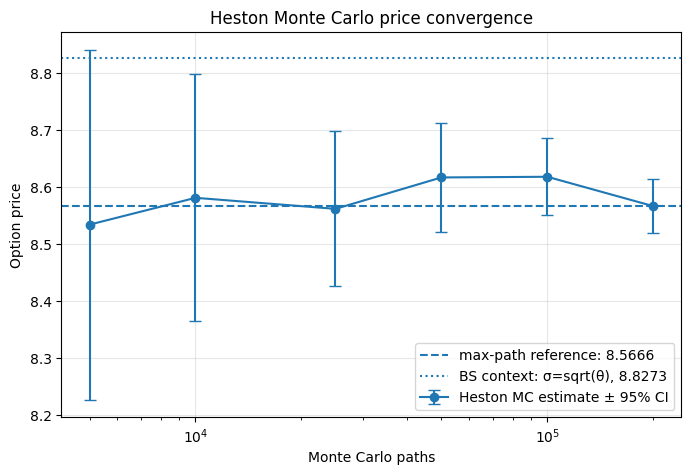

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    convergence["n_paths"],
    convergence["price"],
    yerr=convergence["ci_half_width_95"],
    marker="o",
    capsize=4,
    label="Heston MC estimate ± 95% CI",
)
ax.axhline(reference_price, linestyle="--", label=f"max-path reference: {reference_price:.4f}")
ax.axhline(bs_at_sqrt_theta, linestyle=":", label=f"BS context: σ=sqrt(θ), {bs_at_sqrt_theta:.4f}")

ax.set_xscale("log")
ax.set_xlabel("Monte Carlo paths")
ax.set_ylabel("Option price")
ax.set_title("Heston Monte Carlo price convergence")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## 6) Plot uncertainty decay

For plain Monte Carlo, standard error should scale roughly like `1 / sqrt(n)`. The log-log plot makes that rate easy to inspect.


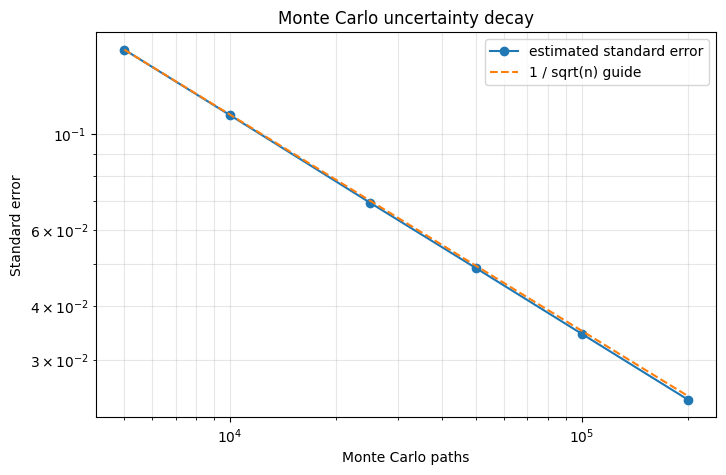

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    convergence["n_paths"],
    convergence["standard_error"],
    marker="o",
    label="estimated standard error",
)

first_n = float(convergence["n_paths"].iloc[0])
first_se = float(convergence["standard_error"].iloc[0])
theory = first_se * np.sqrt(first_n / convergence["n_paths"].to_numpy(dtype=float))
ax.plot(convergence["n_paths"], theory, linestyle="--", label="1 / sqrt(n) guide")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Monte Carlo paths")
ax.set_ylabel("Standard error")
ax.set_title("Monte Carlo uncertainty decay")
ax.grid(True, alpha=0.3, which="both")
ax.legend()
plt.show()


## Notes for extension

- Increase `PROFILE` to `"full"` for a less noisy convergence picture.
- Increase `N_STEPS` when studying discretization bias, not just path-count convergence.
- Add antithetic variates or a Black-Scholes control variate if the goal is variance reduction rather than a transparent baseline.
- Promote the simulator into `option_pricing.models` or `option_pricing.pricers` only after settling the desired Heston discretization and public API.
